#### Pandas
 
- In this notebook, we delve deeper into the use of pandas in data science.

In [27]:
import pandas as pd
from pathlib import Path

data_dir = Path("data")
orders_path = data_dir / "orders.csv"
orders = pd.read_csv(orders_path)

print(orders)

   order_id  customer_id  amount  order_date category
0         1          101   120.5  2024-01-02  premium
1         2          102    75.0  2024-01-03    basic
2         3          103   210.0  2024-01-04    basic
3         4          101    55.0  2024-01-05    basic
4         5          104   320.0  2024-01-06  premium
5         6          101    80.0  2024-01-07    basic
6         7          102   150.0  2024-01-08  premium
7         8          103    90.0  2024-01-09    basic
8         9          104    60.0  2024-01-10  premium


#### Formats:
- `csv` for small and medium size tables.
- `parquet` or `HDF5` for larger tables.

In [9]:
# Clean and save the new artifact

clean_orders = orders.dropna(
    subset=["customer_id", "amount"]
).copy()

clean_orders["amount_eur"] = clean_orders["amount"].round(2)

output_path = data_dir / "orders_clean.parquet"

clean_orders.to_parquet(output_path, index=False, engine="fastparquet")

clean_orders.head()

,order_id,customer_id,amount,order_date,category,amount_eur
0,1,101,120.5,2024-01-02,premium,120.5
1,2,102,75.0,2024-01-03,basic,75.0
2,3,103,210.0,2024-01-04,basic,210.0
3,4,101,55.0,2024-01-05,basic,55.0
4,5,104,320.0,2024-01-06,premium,320.0


In [ ]:
# compact version .assign accepts a lambda function
clean_orders = (
    orders
    .dropna(subset=["customer_id", "amount"])
    .assign(amount_eur=lambda df:df["amount"].round(2))
)

#### Joins and relational thinking

.merge() is the pandas analogue of a SQL LEFT JOIN:
- the join column must be well-understood and clean,
- the how argument controls which rows are kept,
- inspect after join

In [13]:
customer_path = data_dir / "customers.csv"
customers = pd.read_csv(customer_path)

orders_with_customers = orders.merge(
    customers,
    on="customer_id",
    how="left" # keep all orders even if a customer is missing
)

orders_with_customers.head()

,order_id,customer_id,amount,order_date,category,country
0,1,101,120.5,2024-01-02,premium,DE
1,2,102,75.0,2024-01-03,basic,US
2,3,103,210.0,2024-01-04,basic,UK
3,4,101,55.0,2024-01-05,basic,DE
4,5,104,320.0,2024-01-06,premium,US


#### Grouping and summarize

In [22]:
# We use ["amount"] after .groupby("country") to specify that we want to aggregate the 'amount' column only. 
# This selects just the 'amount' column for aggregation, so .agg(total_amount="sum") will compute the sum of amount per country.
# If we omitted ["amount"], .agg would apply to all columns that can be aggregated, which may not be what we want.
country_summary = (
    orders_with_customers
    .groupby("country")["amount"]
    .agg(total_amount="sum")
    .sort_values("total_amount", ascending=False)
)

print(country_summary)

         total_amount
country              
US              605.0
UK              300.0
DE              255.5


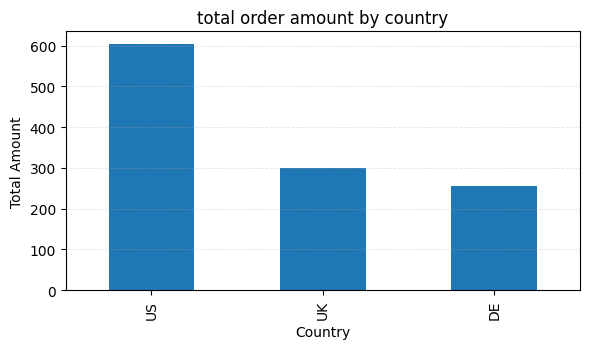

In [ ]:
ax = country_summary.plot(
    kind="bar",
    y="total_amount",
    legend=False,
    figsize=(6.0, 3.6)
)

ax.set_title("total order amount by country")
ax.set_xlabel("Country")
ax.set_ylabel("Total Amount")
ax.grid(
    axis="y", 
    alpha=0.35,
    linestyle="--",
    linewidth=0.6
    )
fig=ax.get_figure()
fig.tight_layout()
fig.savefig("figures/country_total_amounts.pdf")


#### Pivot_table

In [26]:
summary = orders_with_customers.pivot_table(
    index = "customer_id", # One row per customer
    columns = "category", # One column per product category
    values = "amount", # Values to summarize
    aggfunc = "sum", #cum within each customer/category group
    fill_value=0.0 # missing combinations are 0
)

summary.head()

category,basic,premium
customer_id,,
101,135.0,120.5
102,75.0,150.0
103,300.0,0.0
104,0.0,380.0


#### When to use `.apply()`

Use `.apply()` to apply custom functions along a DataFrame axis. However, if a vectorized method exists, it is usually clearer and much faster.

In [28]:
def is_large(amount:float) -> bool:
    """returns true if an order is large"""
    return amount >= 100.0

orders_with_customers["is_large"] = (
    orders_with_customers["amount"].apply(is_large)
    )

orders_with_customers[["order_id", "amount", "is_large"]].head()

,order_id,amount,is_large
0,1,120.5,True
1,2,75.0,False
2,3,210.0,True
3,4,55.0,False
4,5,320.0,True


In [29]:
# Vectoriz comparison

orders_with_customers["is_large_vec"] = (
    orders_with_customers["amount"] >= 100.0
)

orders_with_customers[
    ["order_id", "amount", "is_large", "is_large_vec"]
    ].head()

,order_id,amount,is_large,is_large_vec
0,1,120.5,True,True
1,2,75.0,False,False
2,3,210.0,True,True
3,4,55.0,False,False
4,5,320.0,True,True


#### Method Chaining:
- filter -> group -> summarize -> sort
- Keep chains shallow, keep each step meaningful, and do not be afraid to assign interme-
diate results when clarity improves. Chaining is a readability tool, not a contest to use
as few lines as possible

In [30]:
high_value_summary = (
    orders_with_customers
    .query("amount >= 100") # keep only large orders
    .groupby("country")["amount"] # Group by customer contry
    .agg(total="sum", average="mean", count="size") #summarize
    .sort_values("total", ascending=False) # sort by total amount
)

high_value_summary

,total,average,count
country,,,
US,470.0,235.0,2
UK,210.0,210.0,1
DE,120.5,120.5,1


#### Performace:
- prefer vectorized operations over row-by-row Python loops,
- avoid unnecessary copies of large DataFrames,
- and be explicit about dtypes when reading large files.
- specifying column types can save both memory and confusion:

In [31]:
from numpy import int64


dtypes ={
    "order_id":"int64",
    "customer_id":"int64",
    "amount":"float64",
}
orders = pd.read_csv(orders_path, dtype=dtypes)
